# H5AD → SpatialData and Downstream Analysis

This notebook loads the protein × cell matrix H5AD (from `build_protein_cell_matrix_h5ad.ipynb`) into **SpatialData** and demonstrates downstream applications:

1. **Load H5AD** — Read the AnnData object
2. **Build SpatialData** — Create Points (cell centroids) + Table (AnnData) linked via `region` / `instance_key`
3. **Downstream** — Squidpy spatial neighbors, Scanpy clustering, spatial visualization

---

## Requirements

```bash
pip install spatialdata spatialdata-plot squidpy scanpy anndata
```

---

## Input / Output

| Path | Description |
|------|-------------|
| `output/celldive_protein_matrix.h5ad` | Input: cells × proteins matrix with centroids |
| `output/celldive_sdata.zarr` | Optional: saved SpatialData object |

---

## How to read this notebook

**Flow:** load matrix → build SpatialData → (optional) save → **spatial graph** → **expression Leiden** → *(Napari overlay — optional / commented out)* → **2D scatter plots** → **neighborhood enrichment**.

**Key distinction:** **§7 Leiden** = clusters in **protein PC space**. **§6 / §9** = statistics on **physical proximity** of those labels. A cluster can be **spatially coherent** or **mixed**; both outcomes are biologically meaningful and should be read together with **markers** and **histology** (Napari).

---

## Leiden, Datashader, and Dask (quick reference)

**Leiden clustering** is a method to group cells into **clusters** (communities) using a **graph** built from their data. In this notebook the graph connects each cell to its **k nearest neighbors in PCA space** of **scaled protein expression** (`sc.pp.scale` → `sc.pp.pca` → `sc.pp.neighbors` → `sc.tl.leiden`). Cells in the same cluster tend to have **similar protein profiles**. Leiden is **not** defined by physical `(x, y)` location here—spatial pattern shows up only when you **plot those same labels on a tissue map** (§8) or use **Squidpy** on coordinates (§6, §9). The optional **`resolution`** argument to `sc.tl.leiden` controls granularity: **higher** → typically **more, smaller** clusters; **lower** → **fewer, larger** clusters. (This notebook uses Scanpy’s default resolution unless you change the call.)

**Datashader** is a library for **aggregating huge scatter plots into pixels**. With millions of cells, drawing one matplotlib point per cell is slow and visually useless (everything overlaps). Datashader **bins** points into a grid and computes **per-pixel statistics** (e.g. how many cells land in that bin, or the **sum** of a continuous color value). `spatialdata_plot` with `method="datashader"` uses that pipeline so §8 plots stay usable at **full cell count**. The image you see is a **density / aggregate map**, not a literal list of every point.

**Dask** is a framework for **lazy, chunked** tables and arrays (parallel / out-of-core friendly). **SpatialData** stores the **cell centroid table** (`points["cells"]`) as a **Dask DataFrame** so the whole slide does not need to sit in one giant pandas object. Log messages about Dask or **“Converting … to object dtype”** usually refer to that infrastructure, not to a change in your clustering results.


## 1. Imports

In [12]:
from pathlib import Path

import numpy as np
import anndata as ad
import pandas as pd
import scanpy as sc
import spatialdata as sd
import squidpy as sq
from spatialdata.models import PointsModel, TableModel

import spatialdata_plot  # noqa: F401  # registers plotting methods

## 2. Configuration

In [13]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
INPUT_H5AD = PROJECT_ROOT / "output" / "celldive_protein_matrix.h5ad"
OUTPUT_SDATA = PROJECT_ROOT / "output" / "celldive_sdata.zarr"

# Subsample only when not None: random subset for lighter RAM (e.g. 50_000). None = use all cells.
MAX_CELLS = None

print(f"Input H5AD: {INPUT_H5AD}")
print(f"Output SpatialData: {OUTPUT_SDATA}")
print(f"MAX_CELLS: {MAX_CELLS!r} (None means no subsampling)")


Input H5AD: /home/steve/Projects/HeLab/BladderDIVE/output/celldive_protein_matrix.h5ad
Output SpatialData: /home/steve/Projects/HeLab/BladderDIVE/output/celldive_sdata.zarr
MAX_CELLS: None (None means no subsampling)


## 3. Load H5AD

If `MAX_CELLS` is an integer and `n_obs` exceeds it, the notebook subsamples at random (seed 42) to limit RAM for spatial graphs and plotting. With **`MAX_CELLS = None`**, every cell in the H5AD is kept (expect higher memory use).


In [14]:
adata = ad.read_h5ad(INPUT_H5AD)
if MAX_CELLS is not None and adata.n_obs > MAX_CELLS:
    rng = np.random.default_rng(42)
    idx = rng.choice(adata.n_obs, MAX_CELLS, replace=False)
    adata = adata[idx].copy()
    print(f"Subsampled to {adata.n_obs} cells (MAX_CELLS={MAX_CELLS})")
adata


AnnData object with n_obs × n_vars = 926006 × 23
    obs: 'cell_id', 'area', 'centroid_x', 'centroid_y'
    uns: 'background_estimate', 'background_percentile', 'binary_threshold', 'binary_thresholds', 'data_source', 'sample_id'
    obsm: 'spatial'
    layers: 'binary'

### Interpreting the subsample

If `MAX_CELLS` is set and `n_obs` exceeds it, the notebook keeps a **random subset** (`numpy` RNG seed **42**) for **memory safety**. The subset is **i.i.d. over cells** (not spatially stratified), so dense regions may dominate and rare spatial contexts can be missed.

With **`MAX_CELLS = None`** (current default in this notebook), **all** cells from the H5AD are used—watch RAM on **§6** (spatial neighbors), **§7** (kNN + Leiden), and **§8** plots.

For publication-style clustering on the full cohort while debugging, keep `MAX_CELLS = None` on a machine with enough RAM; otherwise set e.g. `MAX_CELLS = 50_000` again.


## 4. Build SpatialData from H5AD

SpatialData requires:
- **Points**: Cell centroids (x, y) with index matching table rows
- **Table**: AnnData with `region`, `region_key`, `instance_key` linking to Points

We use `cell_id` (or 0-based index) as the instance identifier so the table annotates each point.

In [15]:
# Get centroids from obs or obsm
if "centroid_x" in adata.obs.columns and "centroid_y" in adata.obs.columns:
    x = adata.obs["centroid_x"].values
    y = adata.obs["centroid_y"].values
elif "spatial" in adata.obsm:
    x = adata.obsm["spatial"][:, 0]
    y = adata.obsm["spatial"][:, 1]
else:
    raise ValueError("No centroid coordinates in obs (centroid_x/y) or obsm['spatial']")

# Points need an index. Use cell_id if available, else 0-based.
if "cell_id" in adata.obs.columns:
    instance_ids = adata.obs["cell_id"].values
else:
    instance_ids = np.arange(len(adata))

points_df = pd.DataFrame({"x": x, "y": y}, index=instance_ids)
points_sdata = PointsModel.parse(points_df)
points_sdata

# Add region and instance_key to adata.obs for SpatialData table metadata
REGION_NAME = "cells"
REGION_KEY = "region"
INSTANCE_KEY = "instance_id"

adata.obs[REGION_KEY] = pd.Categorical([REGION_NAME] * len(adata))
adata.obs[INSTANCE_KEY] = instance_ids

# Parse table with annotation metadata
table_sdata = TableModel.parse(
    adata,
    region=REGION_NAME,
    region_key=REGION_KEY,
    instance_key=INSTANCE_KEY,
)

# Build SpatialData
sdata = sd.SpatialData(
    points={REGION_NAME: points_sdata},
    tables={"table": table_sdata},
)
sdata


SpatialData object
├── Points
│     └── 'cells': DataFrame with shape: (<Delayed>, 2) (2D points)
└── Tables
      └── 'table': AnnData (926006, 23)
with coordinate systems:
    ▸ 'global', with elements:
        cells (Points)

### Interpreting the SpatialData object

- **Points `cells`**: one row per cell with **(x, y)**; the index matches **`instance_id`** in the table when you use `cell_id` from the H5AD.
- **Table `table`**: the same **AnnData** (expression, `obs`, `obsm['spatial']`, etc.) with SpatialData **annotation metadata** (`region`, `instance_key`) so plots know which points each row labels.

Anything you do to `sdata.tables["table"]` (Scanpy, Squidpy) is the **same object** the notebook uses for Napari and `spatialdata_plot`—keep §7 and overlays in sync.


## 5. Save SpatialData (optional)

**Note:** If you get `TypeError: Object of type Identity is not JSON serializable`, it's a known PyArrow 22+ compatibility issue. Fix with:

```bash
pip install 'pyarrow<22.0.0'
```

Or upgrade spatialdata to a version that includes the fix (see [scverse/spatialdata#1000](https://github.com/scverse/spatialdata/issues/1000)).

In [16]:
try:
    sdata.write(OUTPUT_SDATA, overwrite=True)
    print(f"Saved to {OUTPUT_SDATA}")
except TypeError as e:
    if "Identity" in str(e) and "JSON serializable" in str(e):
        print("Write failed: PyArrow 22+ compatibility issue. Run: pip install 'pyarrow<22.0.0'")
    else:
        raise

INFO     The Zarr backing store has been changed from None the new file path:                                      
         /home/steve/Projects/HeLab/BladderDIVE/output/celldive_sdata.zarr                                         
Saved to /home/steve/Projects/HeLab/BladderDIVE/output/celldive_sdata.zarr


### Interpreting the Zarr export

Saving writes the **current** points + table (and metadata) to disk. The on-disk table reflects whatever was in memory at write time (e.g. **before** Leiden if you save early). For a reproducible archive that includes clustering, **re-save after §7** or treat this file as **geometry + expression only**.

Downstream sessions can `spatialdata.read_zarr(...)` but must **re-run** analysis cells if the saved object predates clustering.


## 6. Downstream: Squidpy spatial neighbors

Build a spatial graph from cell centroids for neighborhood-based analysis.

In [17]:
sq.gr.spatial_neighbors(sdata["table"])

### Interpreting the spatial neighbor graph (Squidpy)

`squidpy.gr.spatial_neighbors` builds a graph from **cell centroids** (typically Delaunay or distance-based, per Squidpy defaults and your `coord_type`). That graph is used for **spatial statistics** (e.g. §9 enrichment), not for the **Leiden** step above unless you change the pipeline.

**Quality:** Garbage segmentation or **wrong pixel size** in centroids will distort who counts as a “neighbor.” If enrichment patterns look noisy, revisit **segmentation** and **coordinate units** first.


## 7. Downstream: Scanpy clustering

`sc.pp.scale` → `sc.pp.pca` → `sc.pp.neighbors` → `sc.tl.leiden` on the table’s protein matrix. **Run this cell to the end** every time you restart the kernel (a half-run leaves no `obs['leiden']`).

For **what Leiden is** and how it differs from spatial grouping, see **Leiden, Datashader, and Dask** in the notebook introduction.


In [18]:
# Keep one handle so Scanpy and Napari always mutate the same AnnData in sdata.
table = sdata.tables["table"]
sc.pp.scale(table)
sc.pp.pca(table)
sc.pp.neighbors(table)
sc.tl.leiden(table, flavor="igraph")
table.obs["leiden"].value_counts()

leiden
5     77963
11    68900
15    68654
2     67475
1     66509
14    62020
9     48751
16    43856
29    41747
24    41159
27    36669
18    32993
3     31732
4     30181
0     28298
21    22076
8     21826
10    16090
12    15257
22    15134
26    13628
6     13028
32    10939
7     10257
30     9592
28     7967
17     5842
25     4274
31     3249
13     2553
23     2427
33     1483
19     1330
20     1241
34      906
Name: count, dtype: int64

### Interpreting Leiden clusters (§7)

**What this step does (mechanistically):** Each cell is a node in a **k-nearest-neighbor graph** built in **PCA space** after per-gene scaling. **Leiden** partitions that graph into **communities**: sets of cells that are more densely linked to each other than to the rest. The result is a categorical label per cell in `obs['leiden']`. It is **expression-driven**, not defined by imaging morphology or by `(x, y)` alone.

**What it is not:** Unless you explicitly build neighbors from **spatial coordinates**, this is **not** “spatial Leiden.” Tissue-level interpretation comes from **plotting** the same labels in space (§8) and from **Squidpy** tools that use the centroid graph (§6, §9).

**Reading `value_counts`:** Sizes are often **uneven**. Large clusters may be **dominant cell states**; tiny clusters can be **rare types**, **technical edge cases**, or **over-clustering** at the current resolution. Compare with **marker heatmaps** (optional next step) before naming clusters.

**Subsample caveat:** If you set `MAX_CELLS` to an integer, rare populations in the full slide may be **absent or underrepresented**; with `MAX_CELLS = None` you use the full matrix but need enough RAM.


## 9b. Napari (disabled for now)

Full-resolution **Napari** overlay is **commented out** to save GPU/RAM while running on **all** cells. Uncomment the code in the next cell (and optionally restore the longer instructions) when you want the multichannel + Cellpose + Leiden viewer again.

**Notebook order:** when enabled, run §9b after §7. §8 (2D plots) stays below this section in the file.


In [19]:
# --- Napari: uncomment block below to re-enable ---
# import sys
#
# sys.path.insert(0, str(PROJECT_ROOT))
# from scripts.napari_load_image_adata import open_napari_with_adata
#
# t = sdata.tables["table"]
# if "leiden" not in t.obs.columns:
#     # Often §7 was skipped or stopped before the last line; if KNN exists, finish Leiden here.
#     if "connectivities" in t.obsp:
#         sc.tl.leiden(t, flavor="igraph")
#     else:
#         raise RuntimeError(
#             "obs['leiden'] is missing and there is no KNN graph (obsp['connectivities']). "
#             "Run §7 in this kernel through sc.tl.leiden, then re-run this cell.\n"
#             f"Current obs columns: {list(t.obs.columns)!r}"
#         )
#
# _napari_adata = t.copy()  # concrete AnnData for Napari + mask remap
# open_napari_with_adata(
#     _napari_adata,
#     color_column="leiden",
#     project_root=PROJECT_ROOT,
#     display_mode="both",
#     point_size=8,
#     cells_layer_name="Leiden (cell fill)",
# )


### Interpreting the Napari view *(when §9b is enabled)*

- **Image layers**: raw (or registered) CellDIVE channels at **full raster resolution**—use these to relate clusters to **morphology** and known landmarks.
- **Cellpose outline**: segmentation boundary; check for **under-/over-segmentation** where your biology matters.
- **Leiden (cell fill)**: each segmented cell filled by **expression-based cluster**; useful for *local* context. If it is hard to see, **drag that layer above** the multichannel image and **hide** strong channels.
- **Points layers** (one per cluster): **centroids** only—good for spotting **sparse** clusters.

Leiden here is still the **same** partition as §7; Napari does not add a new clustering step.


## 8. Spatial visualization

**Leiden / marker scatter plots** use `plot_sdata_points_datashader` because, at large **n** (e.g. hundreds of thousands of cells), a raw `spatialdata_plot` path can hit an AnnData/SciPy bug when copying neighbor graphs (see `scripts/spatialdata_obsp_plot_workaround.py`).

**Datashader** here turns millions of centroids into a **raster** (per-pixel aggregation); see the intro **“Leiden, Datashader, and Dask”** for intuition. **Dask** backs SpatialData’s point table; benign warnings may appear in the log.

Read the interpretation cells **below each plot** for how to connect these views to §7 and §9b.


WARNING  Annotating points with leiden which is stored in the table `table`. To improve performance, it is         
         advisable to store point annotations directly in the .parquet file.                                       


/home/steve/miniforge3/envs/napari-env/lib/python3.11/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/steve/miniforge3/envs/napari-env/lib/python3.11/site-packages/spatialdata/_core/_elements.py:128: UserWarning: Key `table` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/steve/miniforge3/envs/napari-env/lib/python3.11/site-packages/spatialdata/_core/_elements.py:118: UserWarning: Key `cells` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' do disable this    
         behaviour.                                                                                                


/home/steve/miniforge3/envs/napari-env/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:1123: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/home/steve/miniforge3/envs/napari-env/lib/python3.11/site-packages/spatialdata/_core/_elements.py:118: UserWarning: Key `cells` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/steve/miniforge3/envs/napari-env/lib/python3.11/site-packages/dask/dataframe/core.py:3769: UserWarning: Dask currently has limited support for converting pandas extension dtypes to arrays. Converting string to object dtype.
  warnings.warn(
/home/steve/miniforge3/envs/napari-env/lib/python3.11/site-packages/dask/dataframe/core.py:3769: UserWarning: Dask currently has li

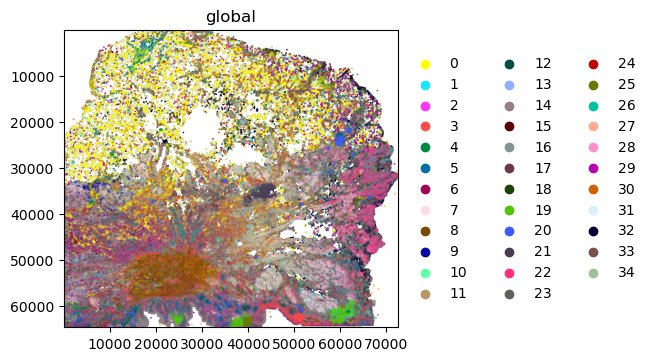

In [20]:
import sys
from pathlib import Path

_root = PROJECT_ROOT if "PROJECT_ROOT" in globals() else (
    Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
)
sys.path.insert(0, str(_root))

import spatialdata_plot  # noqa: F401
from scripts.spatialdata_obsp_plot_workaround import plot_sdata_points_datashader

# Color by Leiden cluster (datashader). Do not replace with a raw sdata.pl.render_points(...) call
# at ~50k cells — that hits an AnnData/SciPy .obsp copy bug inside spatialdata_plot.
plot_sdata_points_datashader(sdata, color="leiden")


### Interpreting the Leiden spatial scatter (datashader)

Each **pixel** in the figure summarizes **many** cells whose centroids fall in that bin. Color encodes **which Leiden cluster dominates** that bin (categorical aggregation). You see **where** large masses of each expression-defined cluster sit in physical space—not every individual point.

**Why datashader:** With roughly a million cells, a normal scatter plot would be a solid smear. Datashader **bins** `(x, y)` and aggregates, so **density and geography** remain visible.

**Dask:** The underlying coordinate table may be a **Dask** DataFrame; plotting still works, but you may see Dask-related warnings in the output.

This view answers: *Do expression-defined clusters **co-localize** in physical space, or mix uniformly?* It is **not** the same as H&E morphology: align mentally with tissue architecture when you use Napari (§9b).

If the plot looks overly **mixed**, try a **lower Leiden resolution** (or fewer PCs / different `n_neighbors`) before over-interpreting fine clusters.



WARNING  Annotating points with CD45 which is stored in the table `table`. To improve performance, it is advisable 
         to store point annotations directly in the .parquet file.                                                 


/home/steve/miniforge3/envs/napari-env/lib/python3.11/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/steve/miniforge3/envs/napari-env/lib/python3.11/site-packages/spatialdata/_core/_elements.py:128: UserWarning: Key `table` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/steve/miniforge3/envs/napari-env/lib/python3.11/site-packages/spatialdata/_core/_elements.py:118: UserWarning: Key `cells` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' do disable this    
         behaviour.                                                                                                
INFO     Using the datashader reduction "sum". "max" will give an output very close to the matplotlib result.      


/home/steve/miniforge3/envs/napari-env/lib/python3.11/site-packages/spatialdata/_core/_elements.py:118: UserWarning: Key `cells` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


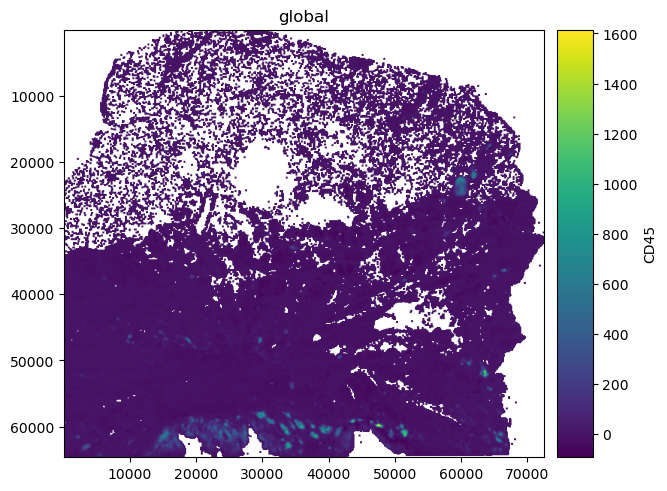

In [21]:
import sys
from pathlib import Path

_root = PROJECT_ROOT if "PROJECT_ROOT" in globals() else (
    Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
)
sys.path.insert(0, str(_root))

import spatialdata_plot  # noqa: F401
from scripts.spatialdata_obsp_plot_workaround import plot_sdata_points_datashader

markers = [v for v in sdata["table"].var_names if v in ["CD45", "CD3E", "CD8a", "PANCK"]]
if markers:
    plot_sdata_points_datashader(sdata, color=markers[0])


### Interpreting the marker spatial scatter

This plot colors centroids by **one protein’s continuous value** in `X` (first matching name in the list). It answers: *Where are the high-expressing cells in space?*

- **Datashader with a continuous color** often **sums** (or otherwise aggregates) intensities inside each pixel bin; the log may say it is using reduction `"sum"` vs `"max"`. **Sum** emphasizes **mass of signal** in crowded regions; **max** is closer to “brightest cell in the bin.” Treat the figure as a **regional summary**, not a single-cell map.
- Compare to **Leiden** (previous plot): a marker should be **enriched** in some clusters if the partition is meaningful.
- **Saturation** in the color scale can hide rare bright cells—cross-check in Napari on a **single channel** (§9b) if needed.
- Channel names must match **`var_names`** exactly (case-sensitive); adjust the `markers` list if a protein is missing.


## 9. Neighborhood enrichment (optional)

Test if clusters are spatially enriched or depleted relative to random.

  0%|          | 0/1000 [00:00<?, ?/s]

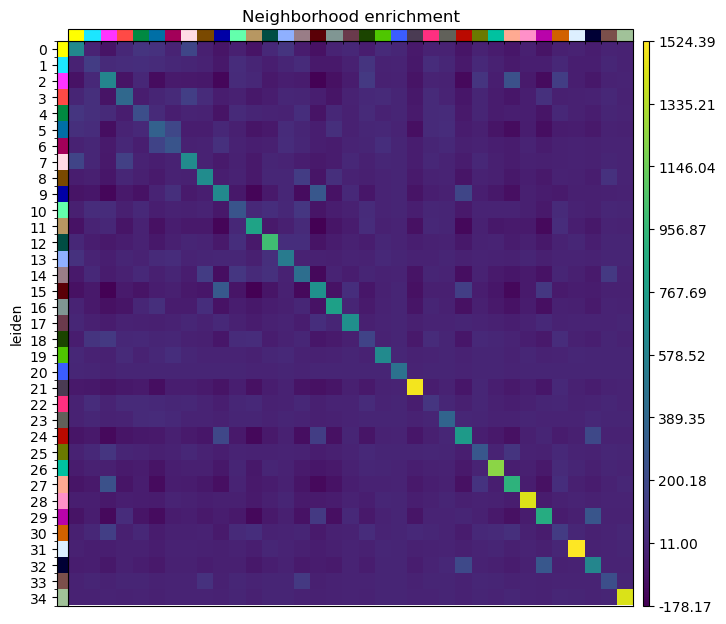

In [22]:
sq.gr.nhood_enrichment(sdata["table"], cluster_key="leiden")
sq.pl.nhood_enrichment(sdata["table"], cluster_key="leiden", figsize=(6, 6))

### Interpreting neighborhood enrichment

The heatmap compares **how often pairs of Leiden clusters touch** in the tissue to what you would expect if cluster labels were **randomly shuffled** while keeping each cell’s position (Squidpy default: permutation-based z-score style scores).

- **Positive values** (hot colors): those two clusters **co-localize** more than chance (e.g. nested or adjacent compartments).
- **Negative values**: **avoidance** or **segregation** relative to random.
- **Rows/columns** are Leiden cluster IDs from the **protein-expression** graph (§7), not a separate spatial cluster run.

Use this as **evidence of spatial organization** of expression-defined states—not as proof of cell–cell signaling. Resolution of the **spatial neighbor graph** (§6) and **segmentation quality** strongly affect results.
